# 03 - Customer Segmentation

Applies K-Means clustering to `customer_features.csv` (built in `data_preprocessing.ipynb`) to group customers into the segments the README calls for: **High-value**, **Regular**, **Occasional**, and **At-risk** customers.

Features used (all from the README's "Customer Segmentation" spec): number of orders, total spending, average order value, order frequency, and recency of purchase.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROCESSED = Path("../Data/processed")
RANDOM_STATE = 42

# Dataviz palette (validated: see project's dataviz skill / references/palette.md)
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
SEQ_SINGLE = "#2a78d6"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "axes.grid": True,
        "grid.color": GRIDLINE,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "figure.dpi": 110,
    }
)

customer_features = pd.read_csv(PROCESSED / "customer_features.csv")
print(customer_features.shape)
customer_features.head()

(77223, 14)


,user_id,total_orders,total_spending,avg_order_value,total_items,first_order_date,last_order_date,recency_days,order_frequency,age,gender,occupation,monthly_income,family_size
0,1,2,1672,836.000000,5,2017-12-12,2018-11-14,591,0.005935,20,Female,Student,No Income,4
1,2,3,4061,1353.666667,7,2018-02-13,2018-08-03,694,0.017544,24,Female,Student,Below Rs.10000,3
2,3,1,21542,21542.000000,500,2019-05-15,2019-05-15,409,1.000000,22,Male,Student,Below Rs.10000,3
3,4,1,102,102.000000,1,2019-02-06,2019-02-06,507,1.000000,22,Female,Student,No Income,6
4,5,2,52047,26023.500000,50,2018-03-02,2018-07-25,703,0.013793,22,Male,Student,Below Rs.10000,4


## 1. Feature Preparation

`exploratory_analysis.ipynb` found `total_spending` and `recency_days` to be heavily right-skewed. K-Means uses Euclidean distance, so a few extreme spenders would otherwise dominate every cluster boundary - log-transform the skewed monetary/frequency features, then standardize everything to zero mean / unit variance so no feature dominates just because of its scale.

In [2]:
feature_cols = ["total_orders", "total_spending", "avg_order_value", "order_frequency", "recency_days"]

print(customer_features[feature_cols].skew().rename("skewness"))

log_cols = ["total_orders", "total_spending", "avg_order_value"]  # skewness > 1

features = customer_features[feature_cols].copy()
features[log_cols] = np.log1p(features[log_cols])

scaler = StandardScaler()
X = scaler.fit_transform(features)

total_orders        1.231572
total_spending     13.029058
avg_order_value    15.793450
order_frequency     0.257761
recency_days        0.322964
Name: skewness, dtype: float64


## 2. Choosing k

The README names four target segments (High-value, Regular, Occasional, At-risk), so `k=4` is the natural business target - but check it against the elbow (inertia) and silhouette score first rather than assuming it's the best statistical fit. Two separate charts (not a dual axis - the metrics are on different scales).

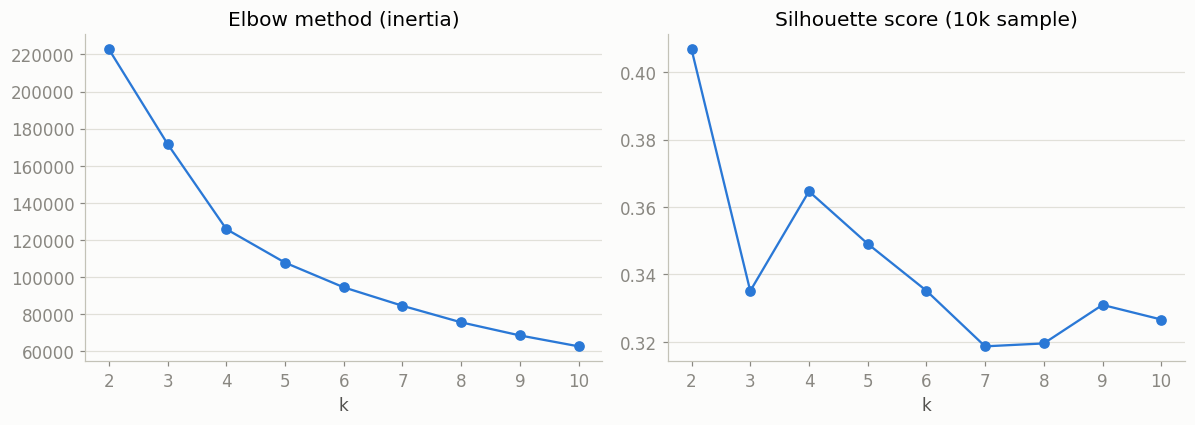

In [3]:
k_range = range(2, 11)
inertias = []
silhouettes = []
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=10_000, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertias, color=SEQ_SINGLE, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")
axes[0].grid(axis="x", visible=False)

axes[1].plot(list(k_range), silhouettes, color=SEQ_SINGLE, marker="o")
axes[1].set_title("Silhouette score (10k sample)")
axes[1].set_xlabel("k")
axes[1].grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

## 3. Fit K-Means (k=4) and Profile Clusters

Fit the final model, then look at each cluster's mean feature values (in original, un-transformed units) to understand what each cluster represents before naming it.

In [4]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
customer_features["cluster"] = kmeans.fit_predict(X)

cluster_profile = (
    customer_features.groupby("cluster")[feature_cols]
    .mean()
    .assign(customers=customer_features["cluster"].value_counts())
    .round(1)
)
cluster_profile

,total_orders,total_spending,avg_order_value,order_frequency,recency_days,customers
cluster,,,,,,
0,2.8,33578.9,12759.2,0.0,297.9,21280
1,1.0,16577.4,16438.1,1.0,523.3,12619
2,1.0,330.7,329.8,1.0,543.5,21470
3,2.4,1509.9,643.9,0.0,356.8,21854


## 4. Name the Clusters

K-Means cluster indices (0-3) are arbitrary and change between runs, so map them to the README's business segments by rank rather than by hardcoded index:

1. **At-risk** - the cluster with the highest mean `recency_days` (haven't ordered in the longest time), regardless of how much they used to spend.
2. **High-value** - among the remaining (more recent) clusters, the one with the highest mean `total_spending`.
3. **Regular** vs. **Occasional** - among the two left, the one with more `total_orders` is Regular, the other Occasional.

In [5]:
remaining = set(cluster_profile.index)

at_risk = cluster_profile["recency_days"].idxmax()
remaining.discard(at_risk)

high_value = cluster_profile.loc[list(remaining), "total_spending"].idxmax()
remaining.discard(high_value)

regular, occasional = sorted(remaining, key=lambda c: cluster_profile.loc[c, "total_orders"], reverse=True)

segment_names = {
    high_value: "High-value",
    regular: "Regular",
    occasional: "Occasional",
    at_risk: "At-risk",
}
customer_features["segment"] = customer_features["cluster"].map(segment_names)

cluster_profile["segment"] = cluster_profile.index.map(segment_names)
cluster_profile

,total_orders,total_spending,avg_order_value,order_frequency,recency_days,customers,segment
cluster,,,,,,,
0,2.8,33578.9,12759.2,0.0,297.9,21280,High-value
1,1.0,16577.4,16438.1,1.0,523.3,12619,Occasional
2,1.0,330.7,329.8,1.0,543.5,21470,At-risk
3,2.4,1509.9,643.9,0.0,356.8,21854,Regular


## 5. Visualize the Segments

Segment is now an identity, not a magnitude, so this is the one place in the project where the categorical palette (not sequential blue) is the right choice - each segment gets its own fixed hue, direct-labeled via the legend since there are only 4 series.

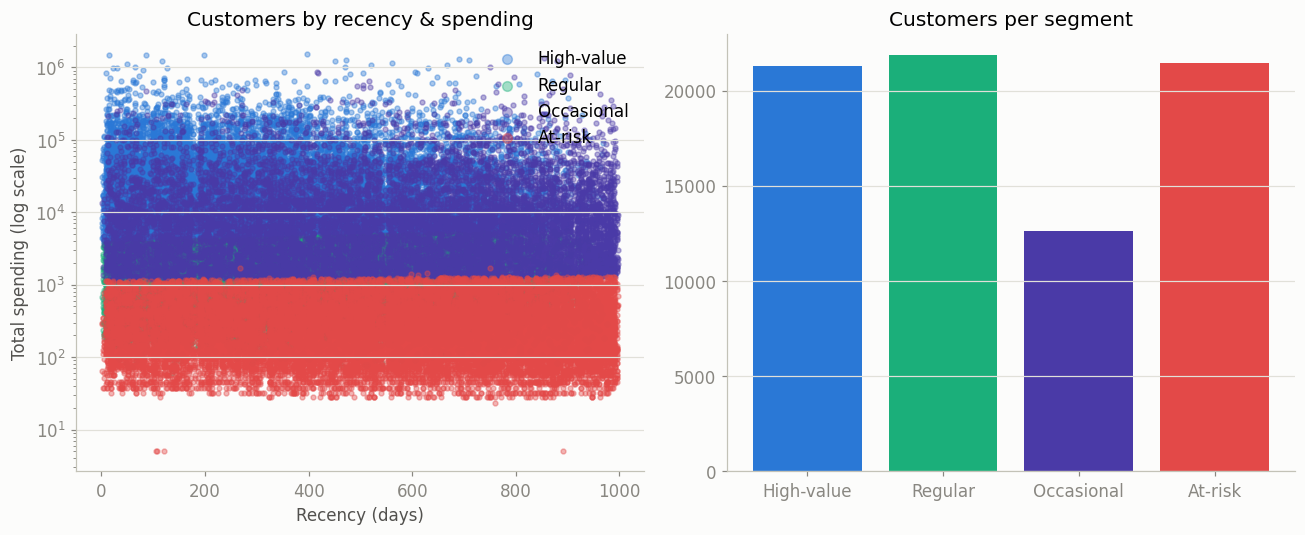

In [6]:
segment_order = ["High-value", "Regular", "Occasional", "At-risk"]

# A scatter plot is an "all-pairs" chart form: every hue is compared against
# every other at once, not just neighbors. The default 8-hue categorical
# order only clears that stricter bar for its first 3 slots (see the
# project's dataviz skill / references/palette.md) - so for these 4 segments
# we hand-pick a subset validated for all-pairs use:
#   node scripts/validate_palette.js "#2a78d6,#1baf7a,#e34948,#4a3aa7" --mode light --pairs all
# -> normal-vision floor 16.3 (clear of the 15 floor); worst CVD pair 6.9
#    (legal in the 6-8 band because the chart carries a direct-label legend).
segment_color = dict(zip(segment_order, ["#2a78d6", "#1baf7a", "#4a3aa7", "#e34948"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for segment in segment_order:
    subset = customer_features[customer_features["segment"] == segment]
    axes[0].scatter(
        subset["recency_days"],
        subset["total_spending"],
        s=10,
        alpha=0.4,
        color=segment_color[segment],
        label=segment,
    )
axes[0].set_yscale("log")
axes[0].set_xlabel("Recency (days)")
axes[0].set_ylabel("Total spending (log scale)")
axes[0].set_title("Customers by recency & spending")
axes[0].legend(markerscale=2, frameon=False)
axes[0].grid(axis="x", visible=False)

segment_sizes = customer_features["segment"].value_counts().reindex(segment_order)
axes[1].bar(segment_sizes.index, segment_sizes.values, color=[segment_color[s] for s in segment_sizes.index])
axes[1].set_title("Customers per segment")
axes[1].grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

**Observation:** the scatter shows the four segments separating cleanly by `total_spending` (the horizontal color bands), but each color spans the full 0-1000 day range on the recency axis almost evenly. In this dataset, spend and order count - not recency - are doing nearly all of the separating work; the recency-based At-risk/High-value split still holds (per the cluster means above) but recency's *effect size* is much smaller than spend's. Worth keeping in mind if recency-driven retention targeting is a priority - it may need its own threshold rule rather than relying on this clustering alone.

## 6. Save Segmented Customers

In [7]:
output_path = PROCESSED / "customer_segments.csv"
customer_features.drop(columns=["cluster"]).to_csv(output_path, index=False)
print(f"Saved {len(customer_features):,} customers to {output_path}")
customer_features["segment"].value_counts().reindex(segment_order)

Saved 77,223 customers to ..\Data\processed\customer_segments.csv


segment
High-value    21280
Regular       21854
Occasional    12619
At-risk       21470
Name: count, dtype: int64

## Summary

`Data/processed/customer_segments.csv` adds a `segment` column (High-value / Regular / Occasional / At-risk) to every row of `customer_features.csv` - ready to join into the Power BI dashboard's Customer Analytics section, or to use as a target/feature for the retention-prediction model.

Next: `market_basket_analysis.ipynb` (Apriori on `order_history_clean.csv`).